# HOW TO TRAIN YOUR BERT MODEL (🤗HuggingFace🤗) 

### Objective : 
Obejctive behind this notebook is to give an idea on building a transformer model using HuggingFace transformers. 

In this noteboook you will see **Basic Text Cleaning, Tokenization, various ways to use a pre-trained Bert model.**

I am trying to keep it as **simple** as i can so that newbie can also understand the workflow.

#### If you learn anything useful from this notebook then **Give Upvote :)

* ## Contents of the Notebook:

### 1) Data Preparation

### 2) Tokenization

### 3) Bert Model
#### - a) By Using only embedding from Bert
#### - b) Fine tuning Bert

In [1]:
import os, re, string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random

#!pip install pySpellChecker
#from spellchecker import SpellChecker               # SpellChecker
from tqdm._tqdm_notebook import tqdm_notebook       # Get progress bar when using pandas
tqdm_notebook.pandas()

seed = 9870
def seeder(seed):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

print(os.listdir('../input'))

['nlp-getting-started']


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:11: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.*` instead of `tqdm._tqdm_notebook.*`
  # This is added back by InteractiveShellApp.init_path()
/opt/conda/lib/python3.7/site-packages/tqdm/std.py:666: FutureWarning: The Panel class is removed from pandas. Accessing it from the top-level namespace will also be removed in the next version
  from pandas import Panel


## EDA

In [2]:
train = pd.read_csv('../input/nlp-getting-started/train.csv')
test = pd.read_csv('../input/nlp-getting-started/test.csv')
sample = pd.read_csv('../input/nlp-getting-started/sample_submission.csv')

In [3]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [5]:
train.describe(include=['O','float','int'])

,id,keyword,location,text,target
count,7613.000000,7552,5080,7613,7613.00000
unique,NaN,221,3341,7503,NaN
top,NaN,fatalities,USA,11-Year-Old Boy Charged With Manslaughter of T...,NaN
freq,NaN,45,104,10,NaN
mean,5441.934848,NaN,NaN,NaN,0.42966
std,3137.116090,NaN,NaN,NaN,0.49506
min,1.000000,NaN,NaN,NaN,0.00000
25%,2734.000000,NaN,NaN,NaN,0.00000
50%,5408.000000,NaN,NaN,NaN,0.00000
75%,8146.000000,NaN,NaN,NaN,1.00000


In [6]:
test.describe(include=['O','float','int'])

,id,keyword,location,text
count,3263.000000,3237,2158,3263
unique,NaN,221,1602,3243
top,NaN,deluged,New York,11-Year-Old Boy Charged With Manslaughter of T...
freq,NaN,23,38,3
mean,5427.152927,NaN,NaN,NaN
std,3146.427221,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN
25%,2683.000000,NaN,NaN,NaN
50%,5500.000000,NaN,NaN,NaN
75%,8176.000000,NaN,NaN,NaN


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3263 non-null   int64 
 1   keyword   3237 non-null   object
 2   location  2158 non-null   object
 3   text      3263 non-null   object
dtypes: int64(1), object(3)
memory usage: 102.1+ KB


# 1) Data Preparation

The very first part of data preparation is EDA. Exploring data will help us in better understanding and also help's in bring out hidden pattern which we may overlook. So let's start EDA
#### Checking for duplicate text data entry

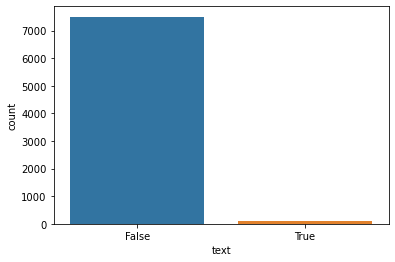

In [9]:
sns.countplot(train.text.duplicated())

Here we can clearly see that there are couple of tweets which are similar. Let.s delete duplicate text and keep only unique tweets

In [10]:
# Deleting duplicate tweets

duplicate_index = train[train.text.duplicated()].index
train.drop(index = duplicate_index, inplace = True)
train.reset_index(drop = True, inplace = True)

### Cleaning -: 
We have to remove all unnecessary symbols, punctuation, tags and many more. ** StopWords should not be removed because transformer learn it while making embedding**

In [11]:
shortforms =   {"ain't": "am not",
    "aren't": "are not",
    "can't": "cannot",
    "can't've": "cannot have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "He had",
    "he'd've": "He would have",
    "he'll": "He will",
    "he'll've": "He will have",
    "he's": "He is",
    "how'd": "How did",
    "how'd'y": "How do you",
    "how'll": "How will",
    "how's": "How is",
    "i'd": "I had",
    "i'd've": "I would have",
    "i'll": "I will",
    "i'll've": "I will have",
    "i'm": "I am",
    "i've": "I have",
    "isn't": "is not",
    "it'd": "It had",
    "it'd've": "It would have",
    "it'll": "It will",
    "it'll've": "It will have",
    "it's": "It is",
    ".it's": "It is",
    "let's": "Let us",
    "ma'am": "Madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "She had",
    "she'd've": "She would have",
    "she'll": "She will",
    "she'll've": "She will have",
    "she's": "She is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so is",
    "that'd": "that had",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "There had",
    "there'd've": "There would have",
    "there's": "There has",
    "they'd": "They had",
    "they'd've": "They would have",
    "they'll": "They will",
    "they'll've": "They will have",
    "they're": "They are",
    "they've": "They have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "We had",
    "we'd've": "We would have",
    "we'll": "We will",
    "we'll've": "We will have",
    "we're": "We are",
    "we've": "We have",
    "weren't": "were not",
    "what'll": "What will",
    "what'll've": "What will have",
    "what're": "What are",
    "what's": "What is",
    "what've": "What have",
    "when's": "When is",
    "when've": "When have",
    "where'd": "Where did",
    "where's": "Where is",
    "where've": "Where have",
    "who'll": "Who will",
    "who'll've": "Who will have",
    "who's": "Who is",
    "who've": "Who have",
    "why's": "Why is",
    "why've": "Why have",
    "will've": "ill have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "You all",
    "y'all'd": "You all would",
    "y'all'd've": "You all would have",
    "y'all're": "You all are",
    "y'all've": "You all have",
    "you'd": "You had",
    "you'd've": "You would have",
    "you'll": "You will",
    "you'll've": "You will have",
    "you're": "You are",
    "you've": "You have"
}

In [12]:
def cleaner(text):
    text = str(text).lower()                                                    # LowerCase
    text = re.sub(r'<*?>',' ',text)                                             # Removing HTML tag
    text = re.sub(r'https?://\S+|www\.\S+',' ',text)                            # Removing hyperlink related entries
    text = ' '.join([shortforms[word] 
                     if word in shortforms.keys() else word
                     for word in text.split()])
    text = str(text).lower()                                                    # LowerCase
    #text = str(text).translate(str.maketrans('','',string.punctuation))         # Removing punctuation
   
    text = re.sub(r'^\s','',text)
    text = re.sub(r'\s+',' ',text)
    
    # Spelling Checker
    
    #spell = SpellChecker()
    #correct = []
    #wrong_words = spell.unknown(text.split())

    #for w in text.split():
    #    if w in wrong_words :
    #        correct.append(spell.correction(w))
    #    else :
    #        correct.append(w)
    
    return(text)

In [13]:
%%time
train['cleaner_text'] = train.text.progress_apply(lambda x: cleaner(x))
test['cleaner_text'] = test.text.progress_apply(lambda x: cleaner(x))


CPU times: user 535 ms, sys: 3.69 ms, total: 538 ms
Wall time: 549 ms


Now given tweets are clean. We can further move to next step for Tokenization

# 2) Tokenization

Now importing HuggingFace transformer's Bert Tokenizer, Base-Model

In [14]:
from transformers import RobertaTokenizer, TFAutoModel, AutoConfig, TFRobertaMainLayer

case = 'roberta-base'

tokenizer = RobertaTokenizer.from_pretrained(case)
config = AutoConfig.from_pretrained(case, output_attentions = True, output_hidden_states = True)
model = TFAutoModel.from_pretrained(case, config = config)
bert = TFRobertaMainLayer(config)

wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


Bert model need two tokens : 1. Input Token id and 2. Attention_id. <br>
Token_id is id corresponding to cleaned input text and attention_id is basically an id which tells model to give attention to corresponding token. For eg. Attention_id will tell model to give more attention to tweet words but ot give attention to paddings

In [15]:
%%time
import tqdm

def convert2token(all_text):
    token_id, attention_id = [], []
    for i, sent in tqdm.tqdm(enumerate(all_text)):
        token_dict = tokenizer.encode_plus(sent, max_length=60, pad_to_max_length=True, return_attention_mask=True, 
                                           return_tensors='tf', add_special_tokens= True)
        token_id.append(token_dict['input_ids'])
        attention_id.append(token_dict['attention_mask'])
    
    token_id = np.array(token_id, dtype='int32')
    attention_id = np.array(attention_id, dtype='int32')
    return(token_id, attention_id)

train_token_id, train_attention_id = convert2token(train.cleaner_text.values)
test_token_id, test_attention_id = convert2token(test.cleaner_text.values)

7503it [00:02, 2658.56it/s]
3263it [00:01, 2568.19it/s]


CPU times: user 2min 1s, sys: 125 ms, total: 2min 1s
Wall time: 2min 2s


# 3) Bert Model

### a) Using Bert model embedding :

Here we will only use embeddings from Bert model and use it as input to another classifier. Here we will be not using Bert's full potential but this might work in some cases

In [16]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

def building_model(need_emb):
    inp_1 = tf.keras.layers.Input(shape = (60,), name = 'token_id', dtype = 'int32')
    inp_2 = tf.keras.layers.Input(shape = (60,), name = 'mask_id', dtype = 'int32')

    x1 = tf.keras.layers.Reshape((60,))(inp_1)
    x2 = tf.keras.layers.Reshape((60,))(inp_2)
    
    if need_emb:
        
        emb = model(x1, attention_mask = x2)[0]     # Give output in form batch_size * max_len_token * hidden_dim, Using only CLS token hidden dimension        
        x = tf.keras.layers.Dense(256, activation = 'relu')(emb[:,0,:])
        x = tf.keras.layers.BatchNormalization() (x)
        x = tf.keras.layers.Dropout(0.3) (x)
        x = tf.keras.layers.Dense(32, activation = 'relu') (x)
        x = tf.keras.layers.BatchNormalization() (x)
        x = tf.keras.layers.Dropout(0.3) (x)

    
    else :
        
        emb = bert(x1, attention_mask = x2)[0]
        x = tf.keras.layers.Dropout(0.2) (emb[:,0,:])


    out = tf.keras.layers.Dense(1, activation = 'sigmoid') (x)

    Emb_Model = tf.keras.models.Model(inputs = [inp_1, inp_2], outputs = out)
    callback = ModelCheckpoint(filepath = 'best.hdf5', monitor = 'val_loss', save_best_only = True, verbose = 1)
    
    # Further more we need to set Bert layer as it is. We don't want to train Bert layer as we are using it as pretrained layer.
    # Setting Bert Layer trainable = False
    
    if need_emb :
        
        for layer in Emb_Model.layers[:5]:
            layer.trainable = False
    
    return(Emb_Model, callback)

In [17]:
Emb_Model, callback = building_model(need_emb=True)
Emb_Model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
token_id (InputLayer)           [(None, 60)]         0                                            
__________________________________________________________________________________________________
mask_id (InputLayer)            [(None, 60)]         0                                            
__________________________________________________________________________________________________
reshape (Reshape)               (None, 60)           0           token_id[0][0]                   
__________________________________________________________________________________________________
reshape_1 (Reshape)             (None, 60)           0           mask_id[0][0]                    
______________________________________________________________________________________________

In [18]:
Emb_Model.compile(metrics=['accuracy'], optimizer=tf.keras.optimizers.Adam(learning_rate = 4e-5), loss='binary_crossentropy')
Emb_Model.fit([np.reshape(train_token_id, (7503,60)), np.reshape(train_attention_id, (7503,60))],  train.target, epochs=10, 
      batch_size=64, validation_split=0.20, shuffle = True)

Epoch 1/10
94/94 [==============================] - 22s 239ms/step - loss: 0.8871 - accuracy: 0.5197 - val_loss: 0.6863 - val_accuracy: 0.5403
Epoch 2/10
94/94 [==============================] - 20s 208ms/step - loss: 0.8020 - accuracy: 0.5648 - val_loss: 0.6726 - val_accuracy: 0.6309
Epoch 3/10
94/94 [==============================] - 20s 211ms/step - loss: 0.7400 - accuracy: 0.6110 - val_loss: 0.6228 - val_accuracy: 0.7575
Epoch 4/10
94/94 [==============================] - 20s 208ms/step - loss: 0.7199 - accuracy: 0.6301 - val_loss: 0.5774 - val_accuracy: 0.7628
Epoch 5/10
94/94 [==============================] - 20s 208ms/step - loss: 0.6780 - accuracy: 0.6563 - val_loss: 0.5367 - val_accuracy: 0.7735
Epoch 6/10
94/94 [==============================] - 20s 210ms/step - loss: 0.6488 - accuracy: 0.6818 - val_loss: 0.5094 - val_accuracy: 0.7781
Epoch 7/10
94/94 [==============================] - 20s 208ms/step - loss: 0.6499 - accuracy: 0.6788 - val_loss: 0.4905 - val_accuracy: 0.7861

In [19]:
%%time
Emb_Model_Answer = Emb_Model.predict([np.reshape(test_token_id, (3263,60)), np.reshape(test_attention_id, (3263,60))])

CPU times: user 7.77 s, sys: 723 ms, total: 8.49 s
Wall time: 12.2 s


### b) Fine tuning Bert:
In this we are going to use all embedding dimension across all tokens and tune it for our task

In [20]:
Tune_Bert,callback = building_model(need_emb = False)
Tune_Bert.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
token_id (InputLayer)           [(None, 60)]         0                                            
__________________________________________________________________________________________________
mask_id (InputLayer)            [(None, 60)]         0                                            
__________________________________________________________________________________________________
reshape_2 (Reshape)             (None, 60)           0           token_id[0][0]                   
__________________________________________________________________________________________________
reshape_3 (Reshape)             (None, 60)           0           mask_id[0][0]                    
____________________________________________________________________________________________

In [21]:
Tune_Bert.compile(metrics=['accuracy'], optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='binary_crossentropy')
Tune_Bert.fit([np.reshape(train_token_id, (7503,60)), np.reshape(train_attention_id, (7503,60))],  train.target, epochs=10, 
      batch_size=64, validation_split=0.20, shuffle = True, callbacks = [callback])

Epoch 1/10
94/94 [==============================] - ETA: 0s - loss: 0.8238 - accuracy: 0.5333
Epoch 00001: val_loss improved from inf to 0.65808, saving model to best.hdf5
94/94 [==============================] - 51s 542ms/step - loss: 0.8238 - accuracy: 0.5333 - val_loss: 0.6581 - val_accuracy: 0.6083
Epoch 2/10
94/94 [==============================] - ETA: 0s - loss: 0.6896 - accuracy: 0.5960
Epoch 00002: val_loss improved from 0.65808 to 0.63311, saving model to best.hdf5
94/94 [==============================] - 49s 520ms/step - loss: 0.6896 - accuracy: 0.5960 - val_loss: 0.6331 - val_accuracy: 0.6243
Epoch 3/10
94/94 [==============================] - ETA: 0s - loss: 0.6149 - accuracy: 0.6693
Epoch 00003: val_loss improved from 0.63311 to 0.55405, saving model to best.hdf5
94/94 [==============================] - 49s 519ms/step - loss: 0.6149 - accuracy: 0.6693 - val_loss: 0.5541 - val_accuracy: 0.7242
Epoch 4/10
94/94 [==============================] - ETA: 0s - loss: 0.5103 - acc

In [22]:
Tune_Bert.load_weights('best.hdf5')
Tune_answer = Tune_Bert.predict([np.reshape(test_token_id, (3263,60)), np.reshape(test_attention_id, (3263,60))])

In [23]:
sample.head(2)

,id,target
0,0,0
1,2,0


In [24]:
answer_Emb = pd.DataFrame({'id': sample.id, 'target': np.where(Emb_Model_Answer>0.5,1,0).reshape(Emb_Model_Answer.shape[0])})
answer_tune = pd.DataFrame({'id': sample.id, 'target': np.where(Tune_answer>0.5,1,0).reshape(Tune_answer.shape[0])})

In [25]:
answer_Emb.to_csv('submission_emb.csv', index = False)
answer_tune.to_csv('submission_tune.csv', index = False)